# Machine Learning-Based Predictive Analytics for Energy Consumption in Smart Grids using Big Data

**Author:** Doaa Abduallah Abdeen | **Course:** ICTS 6339 Big Data, IUG

**Dataset:** [UCI Household Power Consumption](https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption)

**GitHub:** https://github.com/doaaabdeen/BigData


In [1]:
!pip install -q pyspark matplotlib seaborn scikit-learn pandas


In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").appName("SmartGrid").config("spark.driver.memory","4g").getOrCreate()
spark.sparkContext.setLogLevel("WARN")
print("Spark", spark.version)


Spark 4.0.2


In [3]:

import time, json, numpy as np, pandas as pd
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DATA_FILE = "household_power_consumption.txt"
if not Path(DATA_FILE).exists():
    !wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip
    !unzip -q household_power_consumption.zip

def load_data(path):
    t0 = time.time()
    df = pd.read_csv(path, sep=';', na_values=['?'], low_memory=False)
    df.columns = ['Date','Time','Global_active_power','Global_reactive_power','Voltage',
                  'Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']
    df['DateTime'] = pd.to_datetime(df['Date']+' '+df['Time'], format='mixed', dayfirst=True)
    df = df.dropna(subset=['Global_active_power','DateTime'])
    print(f"Loaded {len(df):,} rows in {time.time()-t0:.1f}s")
    return df

def engineer_features(df):
    df = df.copy()
    df['hour'] = df['DateTime'].dt.hour
    df['day_of_week'] = df['DateTime'].dt.dayofweek
    df['month'] = df['DateTime'].dt.month
    df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
    df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
    df['dow_sin'] = np.sin(2*np.pi*df['day_of_week']/7)
    df['dow_cos'] = np.cos(2*np.pi*df['day_of_week']/7)
    df['month_sin'] = np.sin(2*np.pi*df['month']/12)
    df['month_cos'] = np.cos(2*np.pi*df['month']/12)
    df['is_weekend'] = (df['day_of_week']>=5).astype(int)
    df = df.sort_values('DateTime').reset_index(drop=True)
    for lag in [1,3,6,24]:
        df[f'lag_{lag}h_active_power'] = df['Global_active_power'].shift(lag)
    for lag in [1,3]:
        df[f'lag_{lag}h_sub_1'] = df['Sub_metering_1'].shift(lag)
    for w in [3,6,24]:
        df[f'rolling_mean_{w}h'] = df['Global_active_power'].rolling(w, min_periods=1).mean()
    df['total_sub_metering'] = df[['Sub_metering_1','Sub_metering_2','Sub_metering_3']].sum(axis=1)
    feature_cols = ['Global_reactive_power','Voltage','Global_intensity',
        'Sub_metering_1','Sub_metering_2','Sub_metering_3',
        'hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos','is_weekend',
        'lag_1h_active_power','lag_3h_active_power','lag_6h_active_power','lag_24h_active_power',
        'lag_1h_sub_1','lag_3h_sub_1','rolling_mean_3h','rolling_mean_6h','rolling_mean_24h','total_sub_metering']
    df = df.dropna(subset=feature_cols+['Global_active_power'])
    return df, feature_cols

df = load_data(DATA_FILE)
df, feature_cols = engineer_features(df)
X = df[feature_cols].values
y = df['Global_active_power'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train", len(X_train), "Test", len(X_test))


Loaded 2,049,280 rows in 160.4s
Train 1639404 Test 409852


In [4]:

def train_sklearn_models(X_train, X_test, y_train, y_test):
    models = {
        'LinearRegression': LinearRegression(),
        'RandomForest': RandomForestRegressor(n_estimators=30, max_depth=10, n_jobs=-1, random_state=42),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=50, max_depth=5, learning_rate=0.1, random_state=42),
    }
    results = {}
    for name, m in models.items():
        t0 = time.time()
        m.fit(X_train, y_train)
        tr = time.time()-t0
        pred = m.predict(X_test)
        results[name] = {
            'training_time_sec': round(tr,2),
            'metrics': {
                'RMSE': float(np.sqrt(mean_squared_error(y_test, pred))),
                'MAE': float(mean_absolute_error(y_test, pred)),
                'R2': float(r2_score(y_test, pred)),
            }
        }
        print(name, results[name])
    return results

sklearn_results = train_sklearn_models(X_train_s, X_test_s, y_train, y_test)
with open('pandas_benchmark.json','w') as f:
    json.dump({'num_rows_modeled': len(df), 'models': sklearn_results}, f, indent=2)


LinearRegression {'training_time_sec': 4.37, 'metrics': {'RMSE': 0.037357758554037224, 'MAE': 0.023195533203459177, 'R2': 0.9982616838199722}}
RandomForest {'training_time_sec': 356.71, 'metrics': {'RMSE': 0.03257416697031982, 'MAE': 0.01729263149134247, 'R2': 0.9986783581350919}}
GradientBoosting {'training_time_sec': 626.77, 'metrics': {'RMSE': 0.02946886668736468, 'MAE': 0.01741169167596997, 'R2': 0.9989183319074192}}


## Apache Spark MLlib (Big Data Environment)

In [5]:

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression as SparkLR, RandomForestRegressor as SparkRF, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

pdf = df[feature_cols + ['Global_active_power','DateTime']].copy()
pdf['ts'] = pdf['DateTime'].astype('int64')//10**9
sdf = spark.createDataFrame(pdf.drop(columns=['DateTime']))
sdf = sdf.withColumnRenamed('Global_active_power','label')
boundary = sdf.approxQuantile('ts', [0.8], 0.0)[0]
train_sdf = sdf.filter(sdf.ts <= boundary)
test_sdf = sdf.filter(sdf.ts > boundary)
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')

spark_models = {
    'SparkLinearRegression': SparkLR(featuresCol='features', labelCol='label', maxIter=50),
    'SparkRandomForest': SparkRF(featuresCol='features', labelCol='label', numTrees=30, maxDepth=10, seed=42),
    'SparkGBT': GBTRegressor(featuresCol='features', labelCol='label', maxIter=50, maxDepth=5, seed=42),
}
evaluator = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='rmse')
spark_results = {}
for name, algo in spark_models.items():
    pipe = Pipeline(stages=[assembler, algo])
    t0 = time.time()
    fitted = pipe.fit(train_sdf)
    tr = time.time()-t0
    pred = fitted.transform(test_sdf)
    rmse = evaluator.evaluate(pred)
    spark_results[name] = {'training_time_sec': round(tr,2), 'metrics': {'RMSE': round(rmse,6)}}
    print(name, spark_results[name])

with open('spark_benchmark.json','w') as f:
    json.dump({'platform':'pyspark','spark_version': spark.version, 'models': spark_results}, f, indent=2)


SparkLinearRegression {'training_time_sec': 44.55, 'metrics': {'RMSE': 0.037323}}
SparkRandomForest {'training_time_sec': 217.33, 'metrics': {'RMSE': 0.080509}}
SparkGBT {'training_time_sec': 593.64, 'metrics': {'RMSE': 0.079478}}


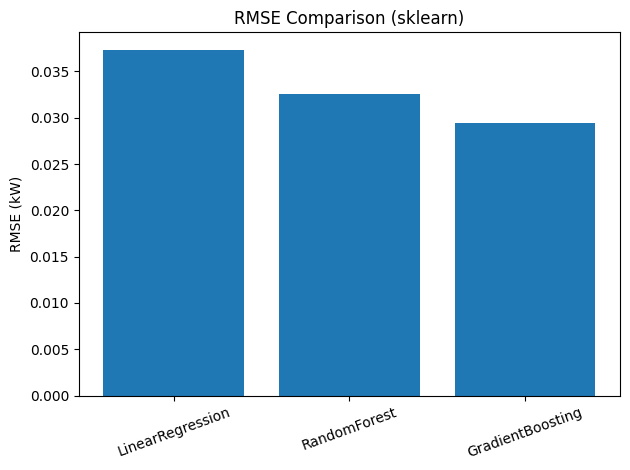

Best: GradientBoosting


In [6]:

import matplotlib.pyplot as plt
models = list(sklearn_results.keys())
rmse = [sklearn_results[m]['metrics']['RMSE'] for m in models]
plt.bar(models, rmse)
plt.title('RMSE Comparison (sklearn)')
plt.ylabel('RMSE (kW)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('fig_rmse.png', dpi=150)
plt.show()
print('Best:', min(sklearn_results, key=lambda k: sklearn_results[k]['metrics']['RMSE']))
